In [1]:
from pathlib import Path
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D


In [2]:
# get best track data for typhoon Ragasa
best_track_ragasa = pd.read_excel("./input/best_track_Ragasa_JMA.xlsx")
best_track_yagi   = pd.read_excel("./input/best_track_Yagi_JMA.xlsx")

In [3]:
# Plot parameters and helper functions.
ROOT = Path.cwd()
if not (ROOT / "input" / "best_track_Ragasa_JMA.xlsx").exists():
    ROOT = Path("Fig1")

INPUT_DIR = ROOT / "input"
OUT_DIR = ROOT / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FONT_FAMILY = "Arial"
DPI = 600
TICK_FONTSIZE = 15
TEXT_FONTSIZE = 15
LABEL_BOX = {
    "boxstyle": "round,pad=0.18",
    "facecolor": "white",
    "edgecolor": "none",
    "alpha": 0.86,
}
TITLE_BOX = {
    "boxstyle": "round,pad=0.25",
    "facecolor": "white",
    "edgecolor": "#ced4da",
    "alpha": 0.92,
}
TIME_LABEL_OFFSETS = [(1, -8), (1, 8), (1, 8), (1, 8), (1, 8), (-1, -8), (1, 8)]

plt.rcParams["font.family"] = FONT_FAMILY

hong_kong_lat = 22.3
hong_kong_lon = 114.1

category_specs = [
    ("Tropical depression", 10.8, 17.1, "#7fc8f8"),
    ("Tropical storm", 17.2, 24.4, "#38b000"),
    ("Severe tropical storm", 24.5, 32.6, "#ffd166"),
    ("Typhoon", 32.7, 41.4, "#f77f00"),
    ("Severe typhoon", 41.5, 50.9, "#d62828"),
    ("Super typhoon", 51.0, np.inf, "#6a040f"),
]


def classify_cn_typhoon(wind_ms):
    for label, lower, upper, color in category_specs:
        if lower <= wind_ms <= upper:
            return label, color
    return "Below tropical depression", "#9e9e9e"


def prepare_best_track(path: Path) -> pd.DataFrame:
    """Read one best-track file and add plotting columns."""
    track = pd.read_excel(path).copy()
    track["time_utc"] = pd.to_datetime(track["Time"].astype(str), format="%y%m%d%H")
    track["lat_deg"] = track["Lat"] / 10.0
    track["lon_deg"] = track["Lon"] / 10.0
    track["wind_ms"] = track["Wind"] * 0.514444
    track[["category", "color"]] = track["wind_ms"].apply(
        lambda value: pd.Series(classify_cn_typhoon(value))
    )
    return track.sort_values("time_utc").reset_index(drop=True)


def interpolate_track_position(
    track: pd.DataFrame,
    target_time: pd.Timestamp,
    before_time: pd.Timestamp,
    after_time: pd.Timestamp,
) -> tuple[float, float]:
    """Linearly interpolate a track position between two best-track records."""
    before = track.loc[track["time_utc"] == before_time].iloc[0]
    after = track.loc[track["time_utc"] == after_time].iloc[0]
    fraction = (target_time - before_time) / (after_time - before_time)
    lon = before["lon_deg"] + fraction * (after["lon_deg"] - before["lon_deg"])
    lat = before["lat_deg"] + fraction * (after["lat_deg"] - before["lat_deg"])
    return lon, lat


def exact_track_position(track: pd.DataFrame, target_time: pd.Timestamp) -> tuple[float, float]:
    """Return the best-track position at an exact timestamp."""
    matches = track.loc[track["time_utc"] == target_time]
    if matches.empty:
        raise ValueError(f"No best-track record found at {target_time:%Y-%m-%d %HZ}")
    point = matches.iloc[0]
    return point["lon_deg"], point["lat_deg"]


def time_label_indices(
    track: pd.DataFrame,
    interval_hours: int = 48,
    label_hour: int = 0,
) -> pd.Index:
    """Select 00Z labels every 48 hours from the first available 00Z record."""
    candidates = track.loc[track["time_utc"].dt.hour == label_hour].copy()
    first_time = candidates["time_utc"].min()
    elapsed_hours = (candidates["time_utc"] - first_time).dt.total_seconds() / 3600
    return candidates.index[elapsed_hours.mod(interval_hours) == 0]


def offset_alignment(x_offset: int, y_offset: int) -> tuple[str, str]:
    """Map annotation offsets to readable horizontal and vertical alignment."""
    ha = "center" if x_offset == 0 else ("left" if x_offset > 0 else "right")
    va = "bottom" if y_offset >= 0 else "top"
    return ha, va


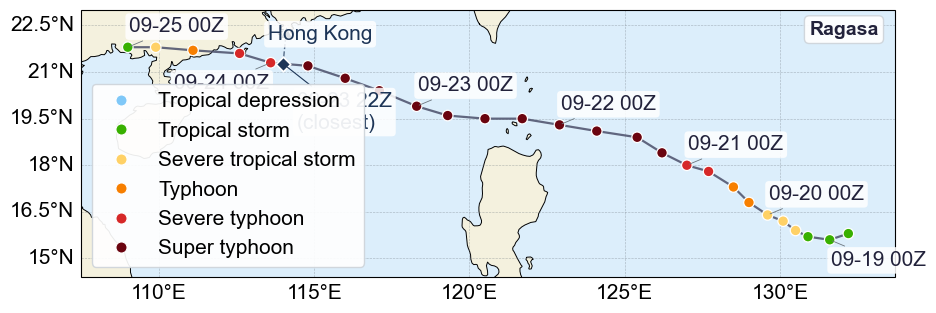

In [4]:
# plot best track for typhoon Ragasa
track = best_track_ragasa.copy()
track['time_utc'] = pd.to_datetime(track['Time'].astype(str), format='%y%m%d%H')
track['lat_deg'] = track['Lat'] / 10.0
track['lon_deg'] = track['Lon'] / 10.0
track['wind_ms'] = track['Wind'] * 0.514444

track[['category', 'color']] = track['wind_ms'].apply(
    lambda value: pd.Series(classify_cn_typhoon(value))
)
track = track.sort_values('time_utc').reset_index(drop=True)

# Interpolate track position at 09-23 22:00 UTC
target_time = pd.Timestamp('2025-09-23 22:00:00')
before_time = pd.Timestamp('2025-09-23 18:00:00')
after_time = pd.Timestamp('2025-09-24 00:00:00')
before_point = track.loc[track['time_utc'] == before_time].iloc[0]
after_point = track.loc[track['time_utc'] == after_time].iloc[0]
time_fraction = (target_time - before_time) / (after_time - before_time)
closest_lat = before_point['lat_deg'] + time_fraction * (after_point['lat_deg'] - before_point['lat_deg'])
closest_lon = before_point['lon_deg'] + time_fraction * (after_point['lon_deg'] - before_point['lon_deg'])

lon_padding = 1.5
lat_padding = 1.2
extent = [
    track['lon_deg'].min() - lon_padding,
    track['lon_deg'].max() + lon_padding,
    track['lat_deg'].min() - lat_padding,
    track['lat_deg'].max() + lat_padding,
]

fig = plt.figure(figsize=(10.5, 5.8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.set_facecolor('#dceefb')
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#f4f1de', edgecolor='none', zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#dceefb', edgecolor='none', zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.7, zorder=1)

gridlines = ax.gridlines(
    draw_labels=True,
    linewidth=0.45,
    color='#6c757d',
    alpha=0.45,
    linestyle='--'
)
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xlabel_style = {'size': TICK_FONTSIZE, 'family': FONT_FAMILY}
gridlines.ylabel_style = {'size': TICK_FONTSIZE, 'family': FONT_FAMILY}

ax.plot(
    track['lon_deg'],
    track['lat_deg'],
    color='#4a4e69',
    linewidth=1.6,
    alpha=0.85,
    transform=ccrs.PlateCarree(),
    zorder=2,
)

ax.scatter(
    track['lon_deg'],
    track['lat_deg'],
    c=track['color'],
    s=58,
    edgecolors='white',
    linewidths=0.9,
    transform=ccrs.PlateCarree(),
    zorder=3,
)

ax.scatter(
    hong_kong_lon,
    hong_kong_lat,
    marker='^',
    s=90,
    facecolor='#1d3557',
    edgecolor='white',
    linewidth=0.9,
    transform=ccrs.PlateCarree(),
    zorder=4,
)
ax.annotate(
    'Hong Kong',
    xy=(hong_kong_lon, hong_kong_lat),
    xytext=(62, 5),
    textcoords='offset points',
    fontsize=TEXT_FONTSIZE,
    fontfamily=FONT_FAMILY,
    color='#1d3557',
    ha='right',
    va='top',
    bbox=LABEL_BOX,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

# Mark the interpolated closest point (09-23 22:00 UTC)
# Dashed line from closest point to Hong Kong
ax.plot(
    [closest_lon, hong_kong_lon],
    [closest_lat, hong_kong_lat],
    color='#1d3557',
    linewidth=1.0,
    linestyle='--',
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    zorder=4,
)

# Highlight the closest point with a diamond marker
ax.scatter(
    closest_lon,
    closest_lat,
    marker='D',
    s=55,
    facecolor='#1d3557',
    edgecolors='white',
    linewidths=1.2,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

# Label the closest point (right bottom)
ax.annotate(
    '09-23 22Z\n(closest)',
    xy=(closest_lon, closest_lat),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=TEXT_FONTSIZE,
    fontfamily=FONT_FAMILY,
    color='#1d3557',
    ha='left',
    va='top',
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle='-', color='#1d3557', linewidth=0.8),
    transform=ccrs.PlateCarree(),
    zorder=5,
)

label_indices = track.index[track['time_utc'].dt.hour == 0]
for order, idx in enumerate(label_indices):
    row = track.loc[idx]
    x_offset, y_offset = TIME_LABEL_OFFSETS[order % len(TIME_LABEL_OFFSETS)]
    ax.annotate(
        row['time_utc'].strftime('%m-%d %HZ'),
        xy=(row['lon_deg'], row['lat_deg']),
        xytext=(x_offset, y_offset),
        textcoords='offset points',
        fontsize=TEXT_FONTSIZE,
        fontfamily=FONT_FAMILY,
        color='#22223b',
        ha='left' if x_offset >= 0 else 'right',
        va='bottom' if y_offset >= 0 else 'top',
        bbox=LABEL_BOX,
        arrowprops=dict(arrowstyle='-', color='#6c757d', linewidth=0.6),
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

ax.text(
    0.98,
    0.96,
    'Ragasa',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=14,
    fontfamily=FONT_FAMILY,
    fontweight='bold',
    color='#22223b',
    bbox=TITLE_BOX,
    zorder=6,
)

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=color, markeredgecolor='white',
           markeredgewidth=0.8, markersize=8, label=label)
    for label, _, _, color in category_specs
]
ax.legend(
    handles=legend_handles,
    loc='lower left',
    frameon=True,
    framealpha=0.92,
    facecolor='white',
    edgecolor='#ced4da',
    fontsize=TEXT_FONTSIZE,
    prop={'family': FONT_FAMILY, 'size': TEXT_FONTSIZE},
)


plt.savefig('./output/best_track_ragasa.tif', dpi=600, bbox_inches='tight')
plt.show()

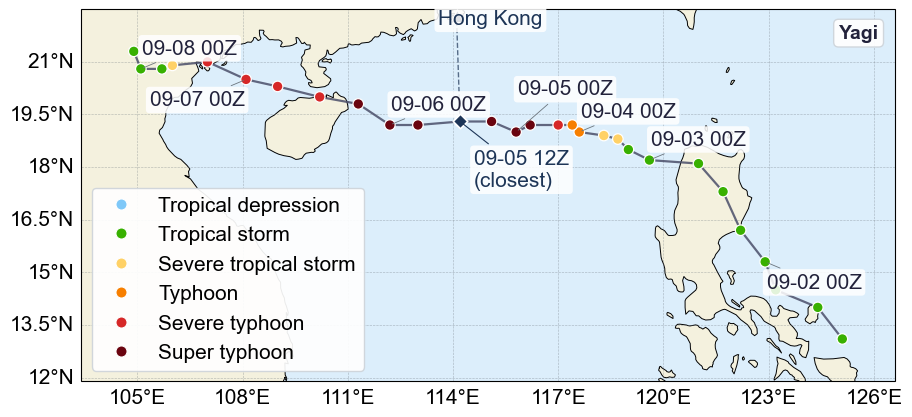

In [5]:
# plot best track for typhoon Yagi
track = best_track_yagi.copy()
track['time_utc'] = pd.to_datetime(track['Time'].astype(str), format='%y%m%d%H')
track['lat_deg'] = track['Lat'] / 10.0
track['lon_deg'] = track['Lon'] / 10.0
track['wind_ms'] = track['Wind'] * 0.514444

track[['category', 'color']] = track['wind_ms'].apply(
    lambda value: pd.Series(classify_cn_typhoon(value))
)

# Mark the best-track point at 09-05 12:00 UTC
target_time = pd.Timestamp('2024-09-05 12:00:00')
closest_matches = track.loc[track['time_utc'] == target_time]
if closest_matches.empty:
    raise ValueError(f'No Yagi best-track record found at {target_time:%Y-%m-%d %HZ}')
closest_point = closest_matches.iloc[0]
closest_lat = closest_point['lat_deg']
closest_lon = closest_point['lon_deg']

lon_padding = 1.5
lat_padding = 1.2
extent = [
    track['lon_deg'].min() - lon_padding,
    track['lon_deg'].max() + lon_padding,
    track['lat_deg'].min() - lat_padding,
    track['lat_deg'].max() + lat_padding,
]

fig = plt.figure(figsize=(10.5, 5.8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(extent, crs=ccrs.PlateCarree())

ax.set_facecolor('#dceefb')
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#f4f1de', edgecolor='none', zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='#dceefb', edgecolor='none', zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.7, zorder=1)

gridlines = ax.gridlines(
    draw_labels=True,
    linewidth=0.45,
    color='#6c757d',
    alpha=0.45,
    linestyle='--'
)
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xlabel_style = {'size': TICK_FONTSIZE, 'family': FONT_FAMILY}
gridlines.ylabel_style = {'size': TICK_FONTSIZE, 'family': FONT_FAMILY}

ax.plot(
    track['lon_deg'],
    track['lat_deg'],
    color='#4a4e69',
    linewidth=1.6,
    alpha=0.85,
    transform=ccrs.PlateCarree(),
    zorder=2,
)

ax.scatter(
    track['lon_deg'],
    track['lat_deg'],
    c=track['color'],
    s=58,
    edgecolors='white',
    linewidths=0.9,
    transform=ccrs.PlateCarree(),
    zorder=3,
)

ax.scatter(
    hong_kong_lon,
    hong_kong_lat,
    marker='^',
    s=90,
    facecolor='#1d3557',
    edgecolor='white',
    linewidth=0.9,
    transform=ccrs.PlateCarree(),
    zorder=4,
)
ax.annotate(
    'Hong Kong',
    xy=(hong_kong_lon, hong_kong_lat),
    xytext=(62, 5),
    textcoords='offset points',
    fontsize=TEXT_FONTSIZE,
    fontfamily=FONT_FAMILY,
    color='#1d3557',
    ha='right',
    va='top',
    bbox=LABEL_BOX,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

# Mark the interpolated closest point (09-05 12:00 UTC)
# Dashed line from closest point to Hong Kong
ax.plot(
    [closest_lon, hong_kong_lon],
    [closest_lat, hong_kong_lat],
    color='#1d3557',
    linewidth=1.0,
    linestyle='--',
    alpha=0.7,
    transform=ccrs.PlateCarree(),
    zorder=4,
)

# Highlight the closest point with a diamond marker
ax.scatter(
    closest_lon,
    closest_lat,
    marker='D',
    s=55,
    facecolor='#1d3557',
    edgecolors='white',
    linewidths=1.2,
    transform=ccrs.PlateCarree(),
    zorder=5,
)

# Label the closest point (right bottom)
ax.annotate(
    '09-05 12Z\n(closest)',
    xy=(closest_lon, closest_lat),
    xytext=(10, -20),
    textcoords='offset points',
    fontsize=TEXT_FONTSIZE,
    fontfamily=FONT_FAMILY,
    color='#1d3557',
    ha='left',
    va='top',
    bbox=LABEL_BOX,
    arrowprops=dict(arrowstyle='-', color='#1d3557', linewidth=0.8),
    transform=ccrs.PlateCarree(),
    zorder=5,
)

label_indices = track.index[track['time_utc'].dt.hour == 0]
for order, idx in enumerate(label_indices):
    row = track.loc[idx]
    x_offset, y_offset = TIME_LABEL_OFFSETS[order % len(TIME_LABEL_OFFSETS)]
    if row['time_utc'] == pd.Timestamp('2024-09-05 00:00:00'):
        x_offset, y_offset = 1, 24
    ax.annotate(
        row['time_utc'].strftime('%m-%d %HZ'),
        xy=(row['lon_deg'], row['lat_deg']),
        xytext=(x_offset, y_offset),
        textcoords='offset points',
        fontsize=TEXT_FONTSIZE,
        fontfamily=FONT_FAMILY,
        color='#22223b',
        ha='left' if x_offset >= 0 else 'right',
        va='bottom' if y_offset >= 0 else 'top',
        bbox=LABEL_BOX,
        arrowprops=dict(arrowstyle='-', color='#6c757d', linewidth=0.6),
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

ax.text(
    0.98,
    0.96,
    'Yagi',
    transform=ax.transAxes,
    ha='right',
    va='top',
    fontsize=14,
    fontfamily=FONT_FAMILY,
    fontweight='bold',
    color='#22223b',
    bbox=TITLE_BOX,
    zorder=6,
)

legend_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=color, markeredgecolor='white',
           markeredgewidth=0.8, markersize=8, label=label)
    for label, _, _, color in category_specs
]
ax.legend(
    handles=legend_handles,
    loc='lower left',
    frameon=True,
    framealpha=0.92,
    facecolor='white',
    edgecolor='#ced4da',
    fontsize=TEXT_FONTSIZE,
    prop={'family': FONT_FAMILY, 'size': TEXT_FONTSIZE},
)


plt.savefig('./output/best_track_yagi.tif', dpi=600, bbox_inches='tight')
plt.show()

[Saved] e:\BaiduSyncdisk\Code\06_AI_WRF_UCM\Figs\Fig1\output\best_track_ragasa_yagi.tif


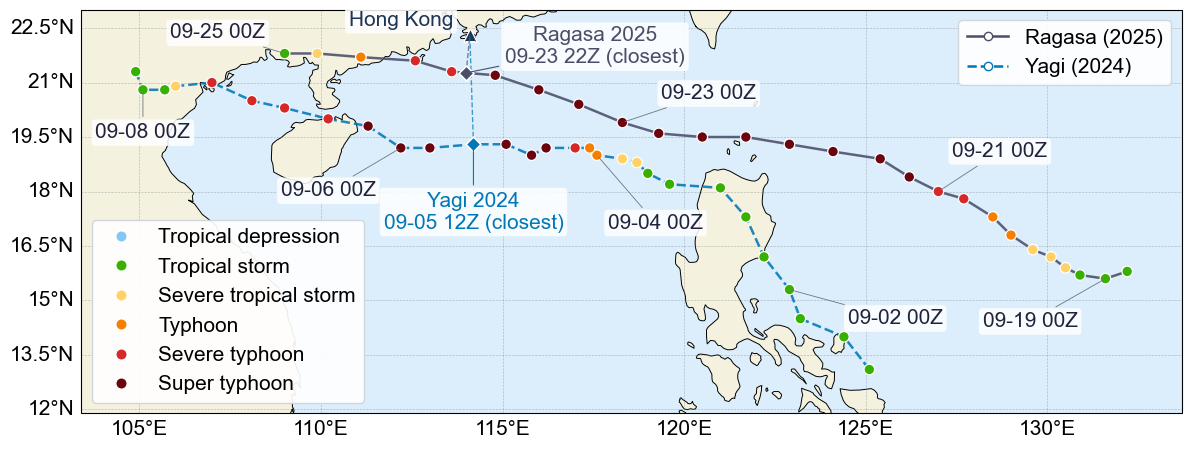

In [6]:
# Plot Ragasa and Yagi best tracks together; save the final figure as TIFF only.
ragasa_track = prepare_best_track(INPUT_DIR / "best_track_Ragasa_JMA.xlsx")
yagi_track = prepare_best_track(INPUT_DIR / "best_track_Yagi_JMA.xlsx")

ragasa_closest = interpolate_track_position(
    ragasa_track,
    target_time=pd.Timestamp("2025-09-23 22:00:00"),
    before_time=pd.Timestamp("2025-09-23 18:00:00"),
    after_time=pd.Timestamp("2025-09-24 00:00:00"),
)
yagi_closest = exact_track_position(yagi_track, pd.Timestamp("2024-09-05 12:00:00"))

combined_track = pd.concat([ragasa_track, yagi_track], ignore_index=True)
extent = [
    combined_track["lon_deg"].min() - 1.5,
    combined_track["lon_deg"].max() + 1.5,
    combined_track["lat_deg"].min() - 1.2,
    combined_track["lat_deg"].max() + 1.2,
]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(14.2, 6.2))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)
ax.set_facecolor("#dceefb")

ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="#f4f1de", edgecolor="none", zorder=0)
ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="#dceefb", edgecolor="none", zorder=0)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.7, zorder=1)

gridlines = ax.gridlines(
    draw_labels=True,
    linewidth=0.45,
    color="#6c757d",
    alpha=0.45,
    linestyle="--",
)
gridlines.top_labels = False
gridlines.right_labels = False
gridlines.xlabel_style = {"size": TICK_FONTSIZE, "family": FONT_FAMILY}
gridlines.ylabel_style = {"size": TICK_FONTSIZE, "family": FONT_FAMILY}

track_styles = {
    "Ragasa": {"data": ragasa_track, "color": "#4a4e69", "linestyle": "-", "label": "Ragasa (2025)"},
    "Yagi": {"data": yagi_track, "color": "#0077b6", "linestyle": "--", "label": "Yagi (2024)"},
}

for style in track_styles.values():
    track = style["data"]
    ax.plot(
        track["lon_deg"],
        track["lat_deg"],
        color=style["color"],
        linewidth=1.8,
        linestyle=style["linestyle"],
        alpha=0.88,
        transform=proj,
        zorder=2,
    )
    ax.scatter(
        track["lon_deg"],
        track["lat_deg"],
        c=track["color"],
        marker="o",
        s=58,
        edgecolors="white",
        linewidths=0.9,
        transform=proj,
        zorder=3,
    )

ax.scatter(
    hong_kong_lon,
    hong_kong_lat,
    marker="^",
    s=90,
    facecolor="#1d3557",
    edgecolor="white",
    linewidth=0.9,
    transform=proj,
    zorder=4,
)
ax.annotate(
    "Hong Kong",
    xy=(hong_kong_lon, hong_kong_lat),
    xytext=(-12, 4),
    textcoords="offset points",
    fontsize=TEXT_FONTSIZE,
    fontfamily=FONT_FAMILY,
    color="#1d3557",
    ha="right",
    va="bottom",
    bbox=LABEL_BOX,
    transform=proj,
    zorder=5,
)

closest_points = [
    {
        "xy": ragasa_closest,
        "label": "Ragasa 2025\n09-23 22Z (closest)",
        "text_xy": (117.55, 22.55),
        "textcoords": proj._as_mpl_transform(ax),
        "color": "#4a4e69",
    },
    {
        "xy": yagi_closest,
        "label": "Yagi 2024\n09-05 12Z (closest)",
        "text_xy": (0, -34),
        "textcoords": "offset points",
        "color": "#0077b6",
    },
]

for point in closest_points:
    lon, lat = point["xy"]
    ax.plot(
        [lon, hong_kong_lon],
        [lat, hong_kong_lat],
        color=point["color"],
        linewidth=1.0,
        linestyle="--",
        alpha=0.7,
        transform=proj,
        zorder=4,
    )
    ax.scatter(
        lon,
        lat,
        marker="D",
        s=58,
        facecolor=point["color"],
        edgecolors="white",
        linewidths=1.2,
        transform=proj,
        zorder=5,
    )
    ax.annotate(
        point["label"],
        xy=(lon, lat),
        xycoords=proj._as_mpl_transform(ax),
        xytext=point["text_xy"],
        textcoords=point["textcoords"],
        fontsize=TEXT_FONTSIZE,
        fontfamily=FONT_FAMILY,
        color=point["color"],
        ha="center",
        va="top",
        bbox=LABEL_BOX,
        arrowprops={"arrowstyle": "-", "color": point["color"], "linewidth": 0.8},
        zorder=5,
    )

label_offsets = {
    "Ragasa": {
        "2025-09-19 00:00:00": (-20, -24),
        "2025-09-21 00:00:00": (10, 22),
        "2025-09-23 00:00:00": (28, 14),
        "2025-09-25 00:00:00": (-14, 8),
    },
    "Yagi": {
        "2024-09-02 00:00:00": (42, -14),
        "2024-09-04 00:00:00": (8, -42),
        "2024-09-06 00:00:00": (-18, -24),
        "2024-09-08 00:00:00": (0, -24),
    },
}

for storm_name, track in [("Ragasa", ragasa_track), ("Yagi", yagi_track)]:
    for idx in time_label_indices(track):
        row = track.loc[idx]
        x_offset, y_offset = label_offsets[storm_name].get(str(row["time_utc"]), (8, 12))
        ha, va = offset_alignment(x_offset, y_offset)
        ax.annotate(
            row["time_utc"].strftime("%m-%d %HZ"),
            xy=(row["lon_deg"], row["lat_deg"]),
            xytext=(x_offset, y_offset),
            textcoords="offset points",
            fontsize=TEXT_FONTSIZE,
            fontfamily=FONT_FAMILY,
            color="#22223b",
            ha=ha,
            va=va,
            bbox=LABEL_BOX,
            arrowprops={"arrowstyle": "-", "color": "#6c757d", "linewidth": 0.6},
            transform=proj,
            zorder=4,
        )

category_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.8,
        markersize=8,
        label=label,
    )
    for label, _, _, color in category_specs
]
category_legend = ax.legend(
    handles=category_handles,
    loc="lower left",
    frameon=True,
    framealpha=0.92,
    facecolor="white",
    edgecolor="#ced4da",
    prop={"family": FONT_FAMILY, "size": TEXT_FONTSIZE},
)
ax.add_artist(category_legend)

storm_handles = [
    Line2D(
        [0],
        [0],
        color=style["color"],
        marker="o",
        markerfacecolor="white",
        markeredgecolor=style["color"],
        linewidth=1.8,
        linestyle=style["linestyle"],
        label=style["label"],
    )
    for style in track_styles.values()
]
ax.legend(
    handles=storm_handles,
    loc="upper right",
    frameon=True,
    framealpha=0.92,
    facecolor="white",
    edgecolor="#ced4da",
    prop={"family": FONT_FAMILY, "size": TEXT_FONTSIZE},
)

out_tif = OUT_DIR / "best_track_ragasa_yagi.tif"
fig.savefig(
    out_tif,
    dpi=DPI,
    format="tiff",
    bbox_inches="tight",
    pil_kwargs={"compression": "tiff_lzw"},
)

print(f"[Saved] {out_tif}")
plt.show()
